In [1]:
library(Seurat)

Warning message:
“package ‘Seurat’ was built under R version 4.2.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.2.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.2.3”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




In [2]:
input_files <- c('/mnt/cold1/snaketree/prj/scRNA/dataset/rCASC_Ire_cetuxi/CRC0322_NT_1_3000_dir/filtered_annotated_CRC0322_NT_1_3000.tsv',
                 '/mnt/cold1/snaketree/prj/scRNA/dataset/rCASC_Ire_cetuxi/CRC0327_NT_2_dir/filtered_annotated_CRC0327_NT_2.tsv', 
                 '/mnt/cold1/snaketree/prj/scRNA/dataset/rCASC_longer/CRC0542_NT72h_1_dir/filtered_annotated_CRC0542_NT72h_1.tsv')
                 
samples <- c('CRC0322', 'CRC0327', 'CRC0542')

filtergenes <- ''
# or 
#filtergenes <- 'Graphs/grafo_filtrato_undirect_small.csv'

if (filtergenes != '') {
    nfeatures <- 949
    npc <- 300
    resolution <- 0.3
} else {
    nfeatures <- 1000
    npc <- 20
    resolution <- 0.08
}


In [3]:
# create seurat objects and integrates
input_files_l <- unlist(strsplit(input_files, ','))

createSeurat <- function(file) {
  df <- read.table(gzfile(file), sep=',', header=TRUE, row.names=1)
  res <- CreateSeuratObject(df)
  return(res)
}

data_list <- lapply(input_files_l, createSeurat)

data_list <- lapply(X = data_list, FUN = function(x) {
    x <- NormalizeData(x)
    x <- FindVariableFeatures(x, selection.method = "vst", nfeatures = nfeatures)
})

features <- SelectIntegrationFeatures(object.list = data_list)
anchors <- FindIntegrationAnchors(object.list = data_list, anchor.features = features)
sdata <- IntegrateData(anchorset = anchors) 
DefaultAssay(sdata) <- "integrated"



Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”
Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”
Warning message:
“Data is of class data.frame. Coercing to dgCMatrix.”
Normalizing layer: counts

Finding variable features for layer counts

Normalizing layer: counts

Finding variable features for layer counts

Normalizing layer: counts

Finding variable features for layer counts

Warning message in CheckDuplicateCellNames(object.list = object.list):
“Some cell names are duplicated across objects provided. Renaming to enforce unique cell names.”
Scaling features for provided objects

Finding all pairwise anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 9611 anchors

Filtering anchors

	Retained 3998 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 8698 anchors

Filtering anchors

	Retained 3647 anchors

Running CCA

Merging objects

Finding neighborhoods

Finding anchors


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
14:15:18 UMAP embedding parameters a = 0.9922 b = 1.112

14:15:18 Read 10050 rows and found 20 numeric columns

14:15:18 Using Annoy for neighbor search, n_neighbors = 30

14:15:18 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

14:15:19 Writing NN index file to temp file /tmp//RtmpCMmXLO/filee5630546c3594

14:15:19 Searching Annoy index using 1 thread, search_k = 3000

14:15:23 Annoy recall = 100%

14:15:24 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbor

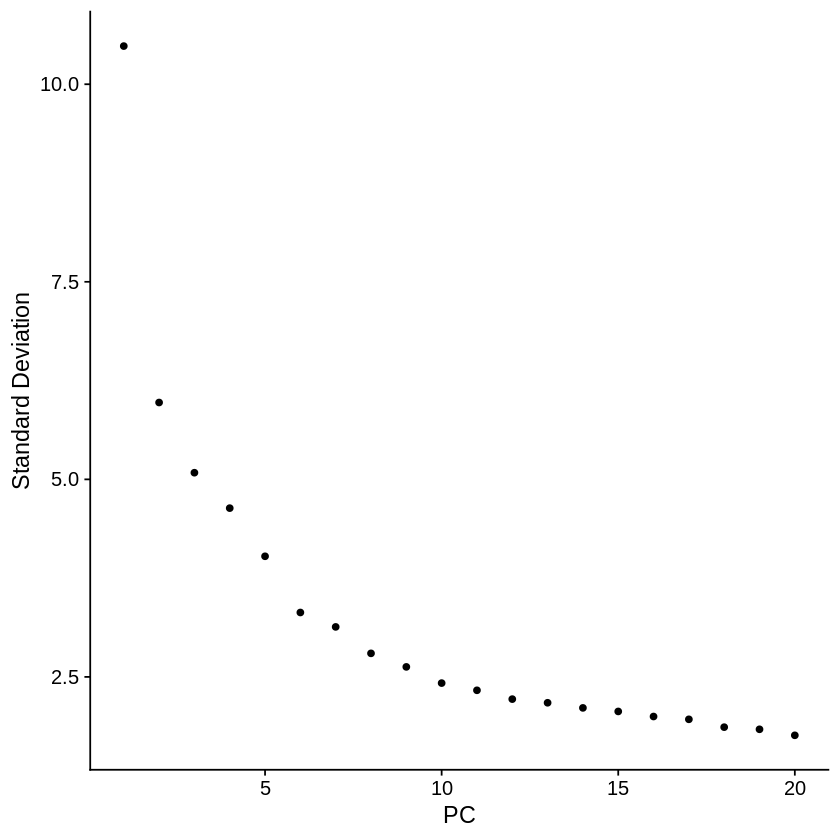

In [4]:
# Scale PCA UMAP on integrated
sdata <- ScaleData(sdata, verbose = FALSE)
sdata <- RunPCA(sdata, verbose = FALSE)

ElbowPlot(sdata)

sdata <- RunUMAP(sdata, reduction = "pca", dims = 1:npc)
sdata <- FindNeighbors(sdata, reduction = "pca", dims = 1:npc, verbose=F)

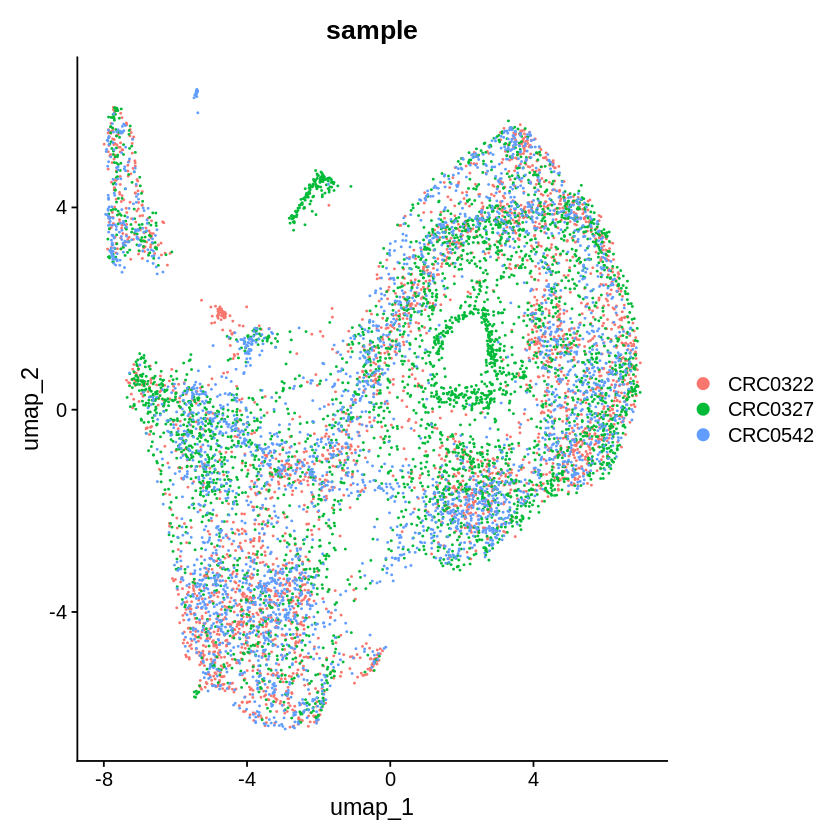

In [5]:
#UMAP with samples
cells <- colnames(sdata)
samples_n <- sapply(strsplit(cells, "_"), function(x){x[[2]]})
sdata$sample <- samples[as.numeric(samples_n)]
DimPlot(sdata, reduction = "umap", group.by='sample')


Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 10050
Number of edges: 386486

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9466
Number of communities: 5
Elapsed time: 1 seconds


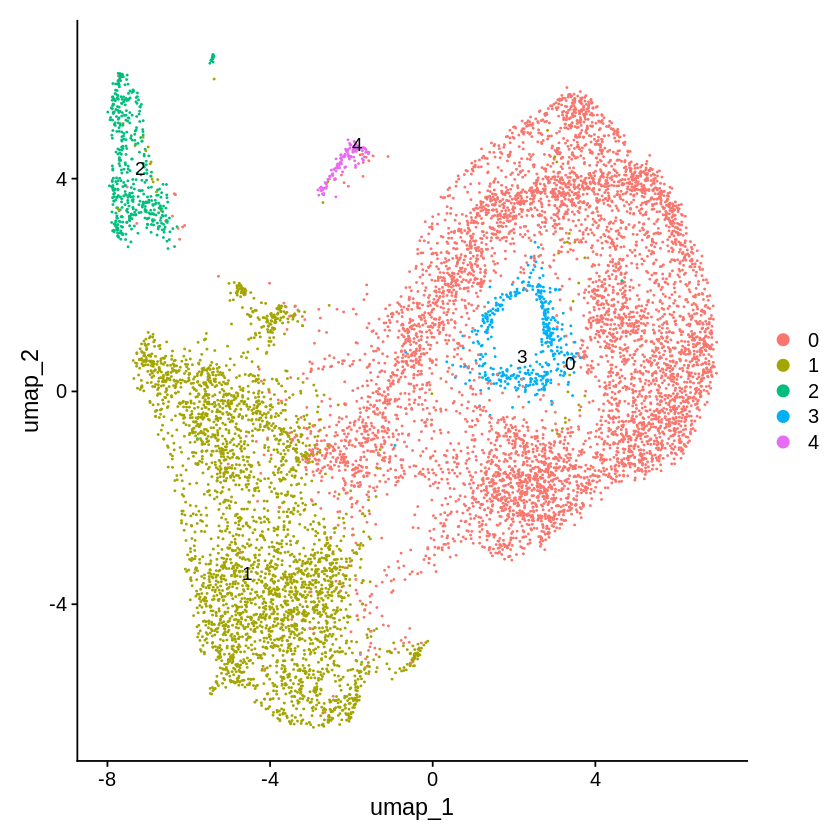

In [6]:
# UMAP with clusters
sdata <- FindClusters(sdata, resolution = resolution)
DimPlot(sdata, reduction = "umap", label = TRUE, repel = TRUE)

In [ ]:
DefaultAssay(sdata) <- "RNA"
sdata <- JoinLayers(sdata)
df <- data.frame(row.names=names(sdata$orig.ident), sample=sdata$sample, cluster=sdata$seurat_clusters)

n_cl <- length(unique(df$cluster))
deg <- list()
for (i in seq(0,(n_cl-1))) {
	cl <- as.data.frame(FindConservedMarkers(sdata, ident.1 = i, verbose = FALSE, grouping.var="sample"))
    deg[[i+1]] <- cl[cl$max_pval < 0.05,]
}


For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session



In [ ]:
length(deg)
n_cl

In [ ]:
for (i in seq(0,(n_cl-1))) {
    print(paste0('cluster ', i))
    d <- deg[[i+1]]
    d <- d[order(-d$CRC0322_avg_log2FC),]
    print(head(d[, grepl('log2FC', colnames(d))], n=10))
    print(head(d[, grepl('adj', colnames(d))], n=10))
}

In [ ]:
filesp <- c('/mnt/cold1/snaketree/prj/scRNA/dataset/KMeans_2/kmeans/CRC0322_NT_1_3000/CRC0322_NT_1_3000_kmeans_2comp.csv',
            '/mnt/cold1/snaketree/prj/scRNA/dataset/KMeans_2/kmeans/CRC0327_NT_2/CRC0327_NT_2_kmeans_2comp.csv',
            '/mnt/cold1/snaketree/prj/scRNA/dataset/KMeans_2/kmeans/CRC0542_NT72h_1/CRC0542_NT72h_1_kmeans_2comp.csv')

load <- function(file) {
  df <- read.csv(file, sep=',', header=TRUE, row.names=1)
  
}
alld <- data.frame()
for (i in seq(1, length(filesp))) {
    data <- read.csv(filesp[i], sep=',', header=TRUE, row.names=1)
    data$cellname <- paste0(rownames(data), '_', i)
    data[data$isPaneth == "filtered", 'isPaneth'] <- 'nPaneth'            
    alld <- rbind(alld, data)
}



In [ ]:
wo <- colnames(sdata)

alld <- alld[match(wo, alld$cellname),]
all(wo == alld$cellname)
sdata$Paneth <- alld$isPaneth
DimPlot(sdata, reduction = "umap", group.by='Paneth')
table(sdata$Paneth, sdata$seurat_clusters)
